#  Manifold Learning

**Manifold learning** is a type of nonlinear dimensionality reduction that assumes high-dimensional data lie on an embedded non-linear manifold within that high-dimensional space. The goal is to discover a low-dimensional representation that preserves important structures of the data.

Dimensionality reduction helps with:
- Visualization (reducing data to 2D/3D)
- Noise reduction
- Feature extraction
- Speeding up machine learning tasks

Unlike PCA (which is linear), manifold learning can capture **nonlinear** structures in data.

### Dataset: The 3D S-Curve

We'll use a synthetic 3D dataset called the S-curve to demonstrate different manifold learning algorithms. The S-curve lies on a 2D nonlinear manifold in 3D space, making it an ideal benchmark for testing dimensionality reduction methods.

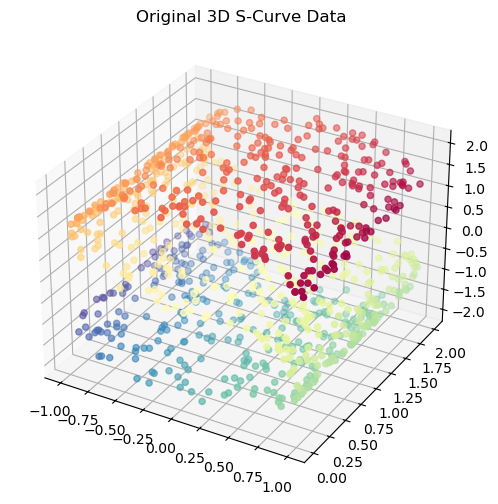

Text(0.5, 0.92, 'Another Angle 3D S-curve')

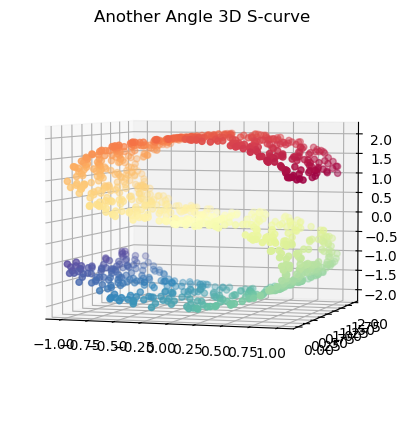

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import manifold, datasets, decomposition
from mpl_toolkits.mplot3d import Axes3D

# Generate a 3D S-curve dataset
n_points = 1000
X, color = datasets.make_s_curve(n_points, random_state=42)

# Plot original 3D data
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, cmap=plt.cm.Spectral)
ax.set_title("Original 3D S-Curve Data")
plt.show()

# 3D plot of the S-curve

from sklearn.datasets import make_s_curve


n_points = 1000
X_scurve, color = make_s_curve(n_points, random_state=0)
n_neighbors = 10
n_components = 2


fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_scurve[:, 0], X_scurve[:, 1], X_scurve[:, 2],
                     c=color, cmap=plt.cm.Spectral)
ax.view_init(4, -72)
plt.title("Another Angle 3D S-curve")

### Principal Component Analysis (PCA) — A Baseline

**Recap:** PCA finds the directions (principal components) that maximize variance. It assumes data lie near a linear subspace.

- Projects data onto orthogonal axes.
- Uses Euclidean distances in high-dimensional space.
- Cannot preserve nonlinear relationships.

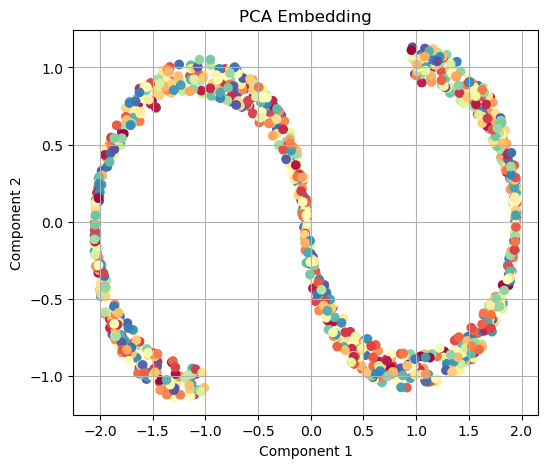

In [2]:
# Define a reusable plotting function
def plot_embedding(X_transformed, title):
    plt.figure(figsize=(6, 5))
    plt.scatter(X_transformed[:, 0], X_transformed[:, 1], c=color, cmap=plt.cm.Spectral)
    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.grid(True)
    plt.show()

# PCA
pca = decomposition.PCA(n_components=2)
X_pca = pca.fit_transform(X)
plot_embedding(X_pca, "PCA Embedding")

**On the S-curve dataset, PCA **fails** to "unroll" the shape—it smashes the curve in a way that loses structure.**

## Multidimensional Scaling (MDS)

**Idea:** Find a configuration of points in lower dimensions that best preserves the **pairwise Euclidean distances** from the original space.

- Solves an optimization problem over all distances.
- Attempts to match a distance matrix using stress minimization.
- Sensitive to nonlinearity because Euclidean distances may not reflect true geometry on a curved manifold.

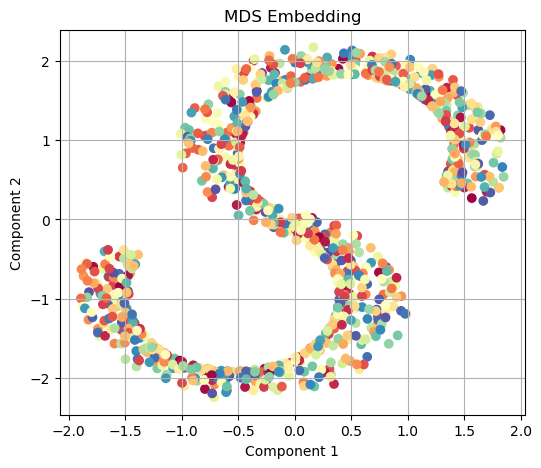

In [3]:
# MDS (Multidimensional Scaling)
mds = manifold.MDS(n_components=2, max_iter=300, n_init=4, random_state=42)
X_mds = mds.fit_transform(X)
plot_embedding(X_mds, "MDS Embedding")

**The MDS plot tries to preserve distance relationships, but it is confused by the S-curve’s curvature. It stretches parts incorrectly, revealing its limitations for non-flat manifolds.**

### Steps to Implement MDS
Consider the **proximity matrix** $D$ that stores pairwise distances of data points $d_{ij} = \text{distance}(x_i,x_j)$:

\begin{align*}
D = \left[\begin{array}{cccc}
d_{11} & d_{12} & \cdots & d_{1N}\\
d_{21} & d_{22} & \cdots & d_{2N}\\
\vdots & \vdots & \ddots & \vdots\\
d_{N1} & d_{N2} & \cdots & d_{NN}
\end{array}\right]
\end{align*}
1. Compute the pairwise **Euclidean distance** matrix \( D \).
2. Compute shortest path 
3. Construct M-dimensional embedding


Note that $D$ is an $N\times N$ symmetric matrix.

Given an assumed Euclidean proximity matrix, $D$, the **goal** of MDS is to find a set of points, $Y$, that have the same proximity matrix in an M-dimensional space, where $M<D$.

* MDS preserves the global data structure.

* MDS can use any distance metric to compute the pairwise distances between points.

* There is the need to store the proximity matrix (half of it, since it is symmetric). Thus requiring a significant computational and storage resources for large datasets. 
    * There are $N(N-1)/2$ distance computations, where $N$ is the number of samples.

* **Classical MDS** refers to MDS when using Euclidean distances.

* In the case where the pairwise distances are computed with the Euclidean distance metric, MDS gives equivalent results to PCA. Therefore, MDS is a generalization of PCA.

## Isomap

In **Isometric feature Mapping**, or **ISOMAP**, the goal is to project the data to a lower-dimensional space using MDS, but where the distance/dissimilarities are defined in terms of the **geodesic distances** measured along the manifold.

- Constructs a k-nearest neighbors graph.
- Computes shortest paths (geodesics) between all pairs using graph algorithms.
- Applies MDS on the resulting distance matrix.



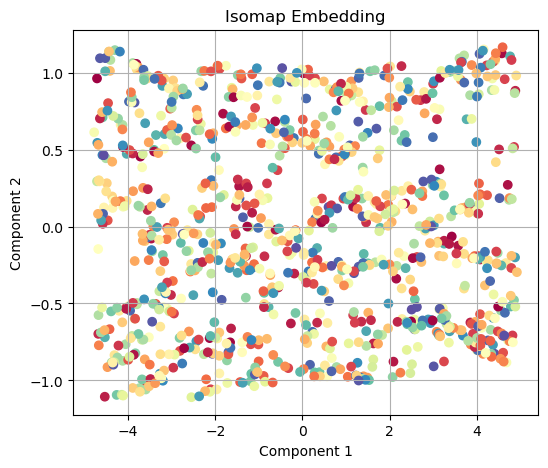

In [4]:
# Isomap
isomap = manifold.Isomap(n_neighbors=10, n_components=2)
X_isomap = isomap.fit_transform(X)
plot_embedding(X_isomap, "Isomap Embedding")

### Shortcomings of ISOMAP

If the data matrix $X\in\mathbb{R}^{N\times D}$ is sufficiently dense, then graph shortest path distance will approximate closely the original geodesic distance.

* ISOMAP may suffer from *non-convexity* such as holes on manifols.

* We need to compute pairwise shortest distance path between **all** sample pairs $(i,j)$. This matrix is a global matrix, non-sparse and it requires cubic complexity $O(N^3)$.

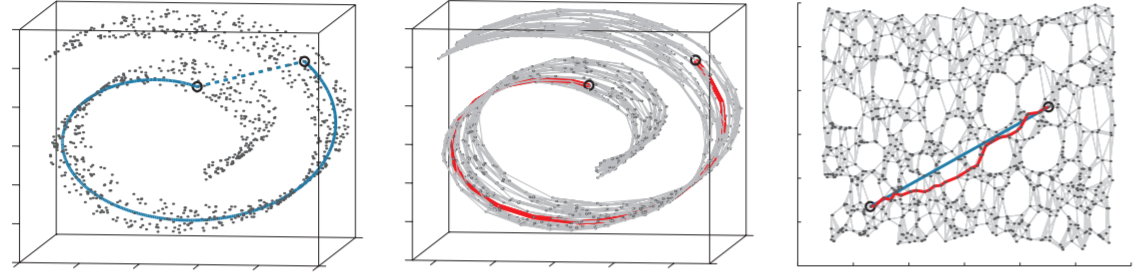

In [5]:
from IPython.display import Image
Image('figures/isomap.png', width=900)

**The Isomap plot successfully "unfolds" the S-curve. By capturing geodesic paths, it preserves both global structure and curvature. This illustrates the power of using manifold-aware distances.**


## Locally Linear Embedding (LLE)

**Idea:** Each data point is approximated by a linear combination of its neighbors in the high-dimensional space. The same weights are used in the low-dimensional embedding.

- Focuses on **local linear relationships**.
- Builds weight matrices from local neighborhoods.
- Optimizes a cost function to preserve these weights in lower dimensions.

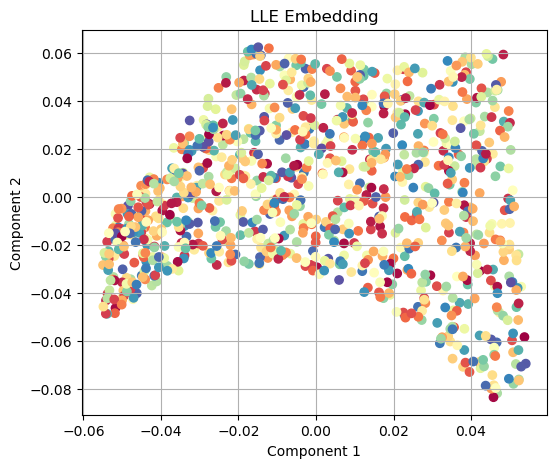

In [6]:
# LLE (Locally Linear Embedding)
lle = manifold.LocallyLinearEmbedding(n_neighbors=10, n_components=2, method='standard')
X_lle = lle.fit_transform(X)
plot_embedding(X_lle, "LLE Embedding")

**LLE preserves the local patches of the manifold well, but the global shape is sometimes distorted. Still, it shows the curve-like continuity of the original data better than PCA or MDS.**

### Steps to Implement LLE
1. For each data point, find its `k` nearest neighbors.
2. Solve a constrained least-squares problem to express the point as a linear combination of neighbors (calculate weights).
3. Solve a sparse eigenvalue problem to find the low-dimensional embedding that best preserves these weights.

## PCA vs. Manifold Learning: When and Why?

### PCA
- Works best when data lies near a linear subspace.
- Very fast, interpretable.
- Poor for nonlinear embeddings.

### Manifold Methods (MDS, Isomap, LLE)
- Reveal latent structures in data lying on curved manifolds.
- Better suited for **visualization** and **nonlinear embeddings**.

| Method | Linear | Uses Euclidean Distance | Uses Geodesic Distance | Global Structure | Local Structure | Strength |
|--------|--------|--------------------------|--------------------------|------------------|------------------|----------|
| PCA    | ✅     | ✅                       | ❌                       | ✅               | ❌               | Fast, interpretable |
| MDS    | ✅     | ✅                       | ❌                       | ✅               | ❌               | Pairwise distance preservation |
| Isomap | ❌     | ❌                       | ✅                       | ✅               | ✅               | Manifold unrolling |
| LLE    | ❌     | ✅ (local only)          | ❌                       | ❌               | ✅               | Local neighborhood fidelity |

---

## Visual Summary

- **PCA**: flattens S-curve, distorting nonlinear structure.
- **MDS**: respects pairwise distances but can't see manifold's shape.
- **Isomap**: uses geodesic paths to unfold the true geometry.
- **LLE**: preserves small local neighborhoods well.

These insights guide model selection:
- Use **PCA** for quick, linear reduction.
- Use **Isomap** for smooth, nonlinear unfolding.
- Use **LLE** when preserving local clusters or neighborhoods matters.

---


## Deciding Number of Dimensions

Interpretability of the MDS solution is often important, and lower dimensional solutions will typically be easier to interpret and visualize. However, dimension selection is also an issue of balancing underfitting and overfitting. Lower dimensional solutions may underfit by leaving out important dimensions of the dissimilarity data. Higher dimensional solutions may overfit to noise in the dissimilarity measurements. 

* How would you decide on the number of dimensions?

**Model selection tools like cross-validation on the subsequent module in the pipeline (e.g. classification) can thus be useful to select the dimensionality that balances underfitting and overfitting.**

## Test the Results for Reliability and Validity

Compute R-squared to determine what proportion of variance of the scaled data can be accounted for by the manifold learning procedure. An R-square of 0.6 is considered the minimum acceptable level. An R-square of 0.8 is considered good for metric scaling and .9 is considered good for non-metric scaling.

---

# Interpretation and Visualization Example - MNIST Dataset

In [7]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import Isomap
from sklearn.manifold import LocallyLinearEmbedding as LLE
from sklearn.manifold import MDS
plt.rcParams['axes.grid'] = False
from time import time

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


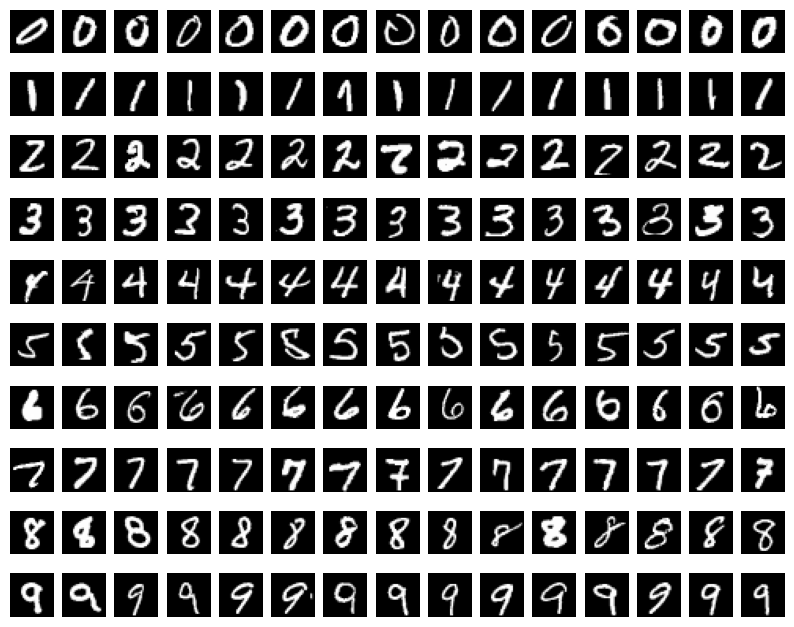

In [8]:
import tensorflow as tf

(images, labels), (images_test, labels_test) = tf.keras.datasets.mnist.load_data()

images = images/255.
images_test = images_test/255.
print(images.shape,labels.shape,images_test.shape,labels_test.shape)

# Flattening image into vector
N,D,_ = images.shape
Ntest,D,_ = images_test.shape
X = images.flatten().reshape(N, D*D)
X_test = images_test.flatten().reshape(Ntest, D*D)

grid=1
plt.figure(figsize=(10,8))
for i in range(10):
    idx_labels = np.random.permutation(np.where(labels==i)[0])
    for j in range(15):
        plt.subplot(10,15,grid)
        plt.imshow(images[idx_labels[j],:,:], cmap='gray')
        plt.axis('off');
        grid+=1

PCA: 0.05 sec


C:\Users\aramirezsalgado\AppData\Local\Temp\ipykernel_37348\1908255040.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.scatter(proj[:, 0], proj[:, 1], c=target, cmap=plt.cm.get_cmap('jet', 10))


MDS: 1.3e+02 sec


C:\Users\aramirezsalgado\AppData\Local\Temp\ipykernel_37348\1908255040.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.scatter(proj[:, 0], proj[:, 1], c=target, cmap=plt.cm.get_cmap('jet', 10))
C:\Users\aramirezsalgado\AppData\Local\anaconda3\envs\ramirez_env\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\aramirezsalgado\AppData\Local\anaconda3\envs\ramirez_env\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = sub

ISOMAP: 2.7 sec


C:\Users\aramirezsalgado\AppData\Local\Temp\ipykernel_37348\1908255040.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.scatter(proj[:, 0], proj[:, 1], c=target, cmap=plt.cm.get_cmap('jet', 10))


LLE: 1.2 sec


C:\Users\aramirezsalgado\AppData\Local\Temp\ipykernel_37348\1908255040.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.scatter(proj[:, 0], proj[:, 1], c=target, cmap=plt.cm.get_cmap('jet', 10))


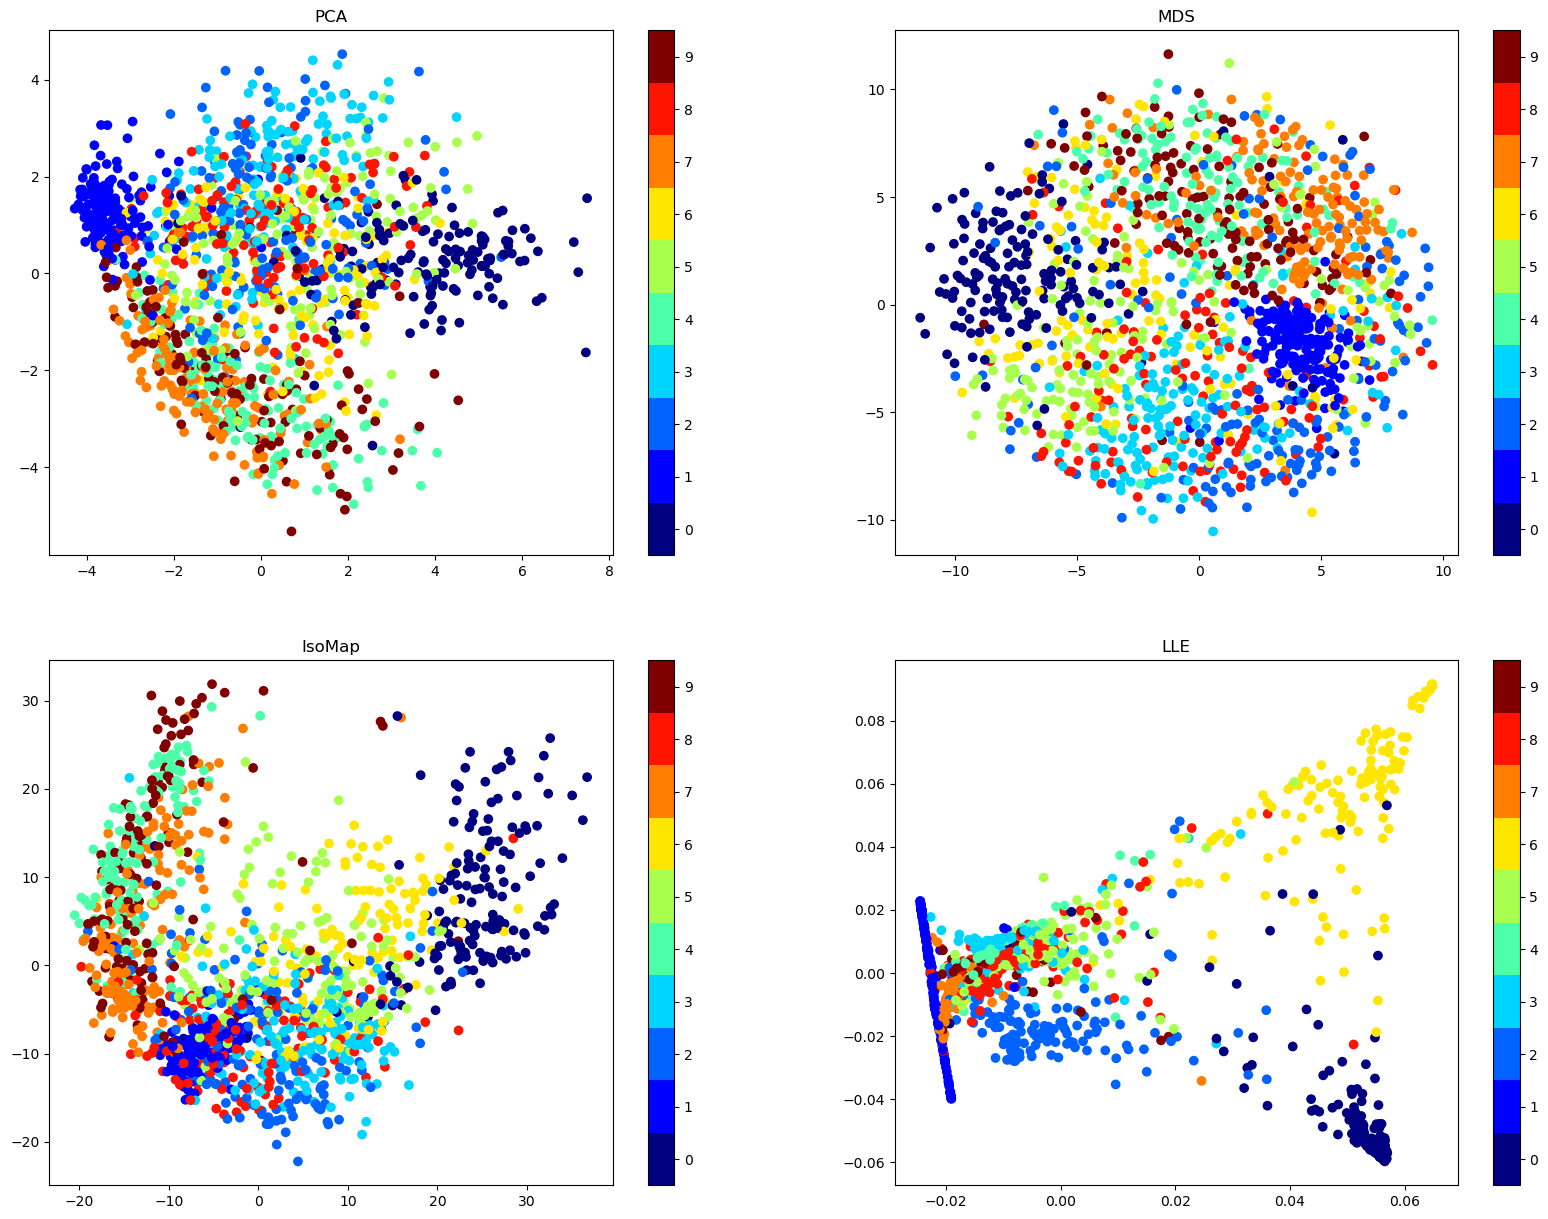

In [9]:
# use only 1/40 of the data: full dataset takes a long time!
data = X[::40]
target = labels[::40]

plt.figure(figsize=(20,15))

#PCA
t0 = time()
model = PCA(n_components=2)
proj = model.fit_transform(data)
t1 = time()
print("PCA: %.2g sec" % (t1 - t0))
plt.subplot(2,2,1)
plt.scatter(proj[:, 0], proj[:, 1], c=target, cmap=plt.cm.get_cmap('jet', 10))
plt.colorbar(ticks=range(10))
plt.clim(-0.5, 9.5);
plt.title('PCA')

#MDS
t0 = time()
model = MDS(n_components=2)
proj = model.fit_transform(data)
t1 = time()
print("MDS: %.2g sec" % (t1 - t0))
plt.subplot(2,2,2)
plt.scatter(proj[:, 0], proj[:, 1], c=target, cmap=plt.cm.get_cmap('jet', 10))
plt.colorbar(ticks=range(10))
plt.clim(-0.5, 9.5);
plt.title('MDS')

# IsoMap
t0 = time()
model = Isomap(n_components=2)
proj = model.fit_transform(data)
t1 = time()
print("ISOMAP: %.2g sec" % (t1 - t0))
plt.subplot(2,2,3)
plt.scatter(proj[:, 0], proj[:, 1], c=target, cmap=plt.cm.get_cmap('jet', 10))
plt.colorbar(ticks=range(10))
plt.clim(-0.5, 9.5);
plt.title('IsoMap')

# LLE
t0 = time()
model = LLE(n_components=2)
proj = model.fit_transform(data)
t1 = time()
print("LLE: %.2g sec" % (t1 - t0))
plt.subplot(2,2,4)
plt.scatter(proj[:, 0], proj[:, 1], c=target, cmap=plt.cm.get_cmap('jet', 10))
plt.colorbar(ticks=range(10))
plt.clim(-0.5, 9.5);
plt.title('LLE');

Let's now interpret the new embedding dimensions via visualization: 

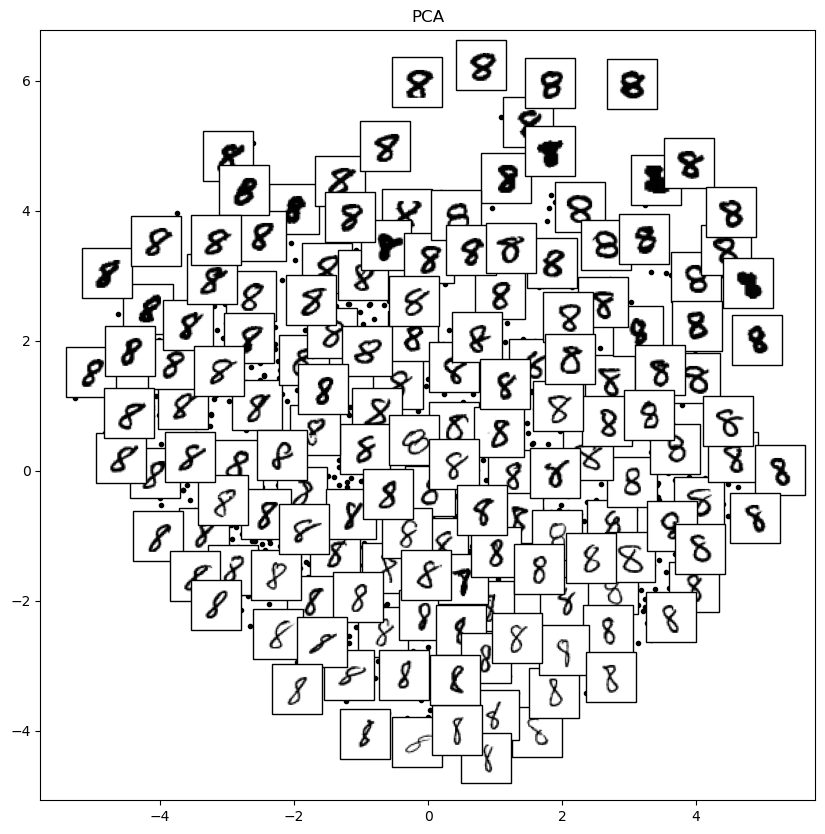

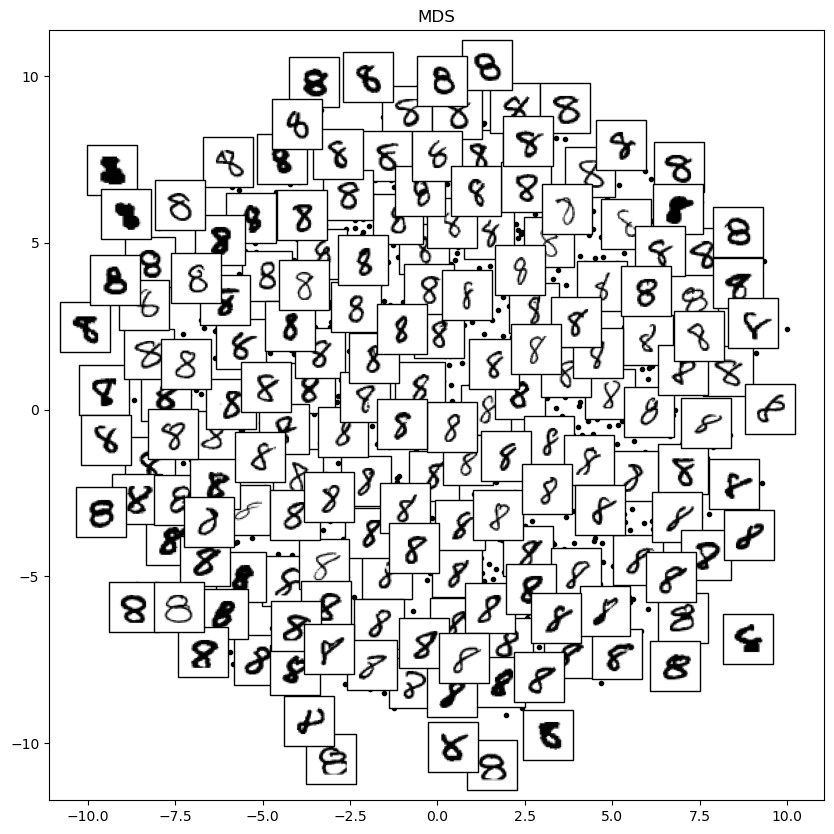

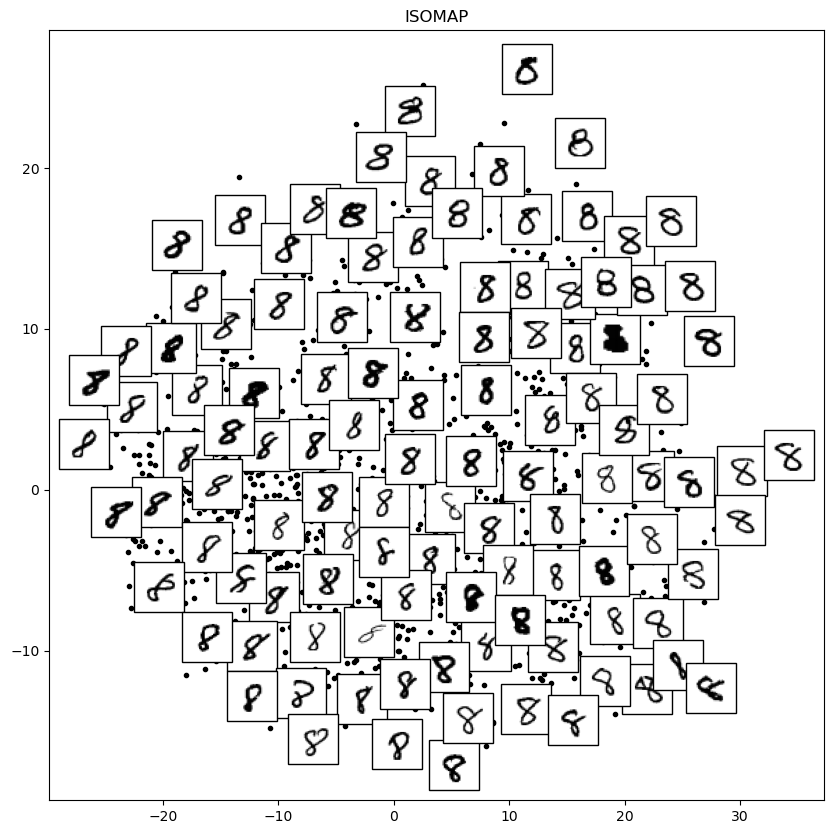

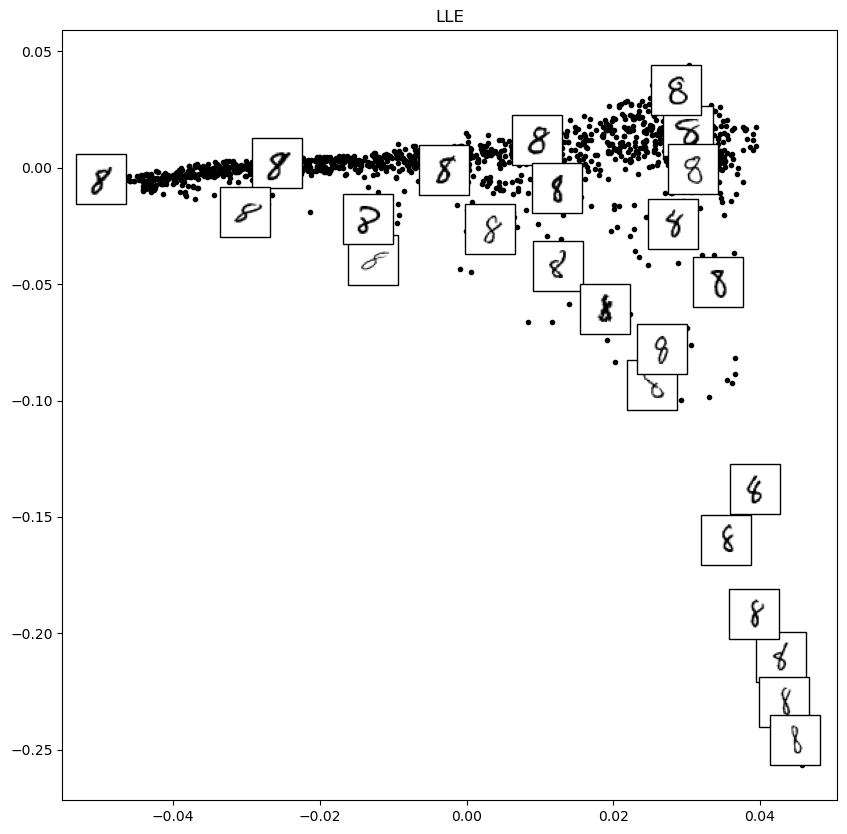

In [10]:
from matplotlib import offsetbox
def plot_components(data, model, images=None, ax=None,
                    thumb_frac=0.05, cmap='gray'):
    ax = ax or plt.gca()
    
    proj = model.fit_transform(data)
    ax.plot(proj[:, 0], proj[:, 1], '.k')
    
    if images is not None:
        min_dist_2 = (thumb_frac * max(proj.max(0) - proj.min(0))) ** 2
        shown_images = np.array([2 * proj.max(0)])
        for i in range(data.shape[0]):
            dist = np.sum((proj[i] - shown_images) ** 2, 1)
            if np.min(dist) < min_dist_2:
                # don't show points that are too close
                continue
            shown_images = np.vstack([shown_images, proj[i]])
            imagebox = offsetbox.AnnotationBbox(
                offsetbox.OffsetImage(images[i], cmap=cmap),
                                      proj[i])
            ax.add_artist(imagebox)

#%% 
# Choose 1/4 of the "1" digits to project
digit = 8
X = images.flatten().reshape(N, D*D)
data = X[labels == digit,:][::4]

# PCA
fig, ax = plt.subplots(figsize=(10, 10))
model = PCA(n_components=2)
plot_components(data, model, images=data.reshape((-1, 28, 28)),
                ax=ax, thumb_frac=0.05, cmap='gray_r')
plt.title('PCA')

# MDS
fig, ax = plt.subplots(figsize=(10, 10))
model2 = MDS(n_components=2, max_iter=100, n_init=1)
plot_components(data, model2, images=data.reshape((-1, 28, 28)),
                ax=ax, thumb_frac=0.05, cmap='gray_r')
plt.title('MDS')

# ISOMAP
fig, ax = plt.subplots(figsize=(10, 10))
model3 = Isomap(n_components=2)
plot_components(data, model3, images=data.reshape((-1, 28, 28)),
                ax=ax, thumb_frac=0.05, cmap='gray_r')
plt.title('ISOMAP');

# LLE
fig, ax = plt.subplots(figsize=(10, 10))
model3 = LLE(n_components=2, n_neighbors=5)
plot_components(data, model3, images=data.reshape((-1, 28, 28)),
                ax=ax, thumb_frac=0.05, cmap='gray_r')
plt.title('LLE');

--- 

# Clustering with K-Means & DBSCAN

<div class="alert alert-info">
    <b>Clustering</b>
    
Clustering is a type of *unsupervised* Machine Learning technique. Clustering algorithms seek to learn, from the properties of the data, an optimal division or discrete labeling of groups of points.
</div>

Suppose you collect pictures of the following objects:

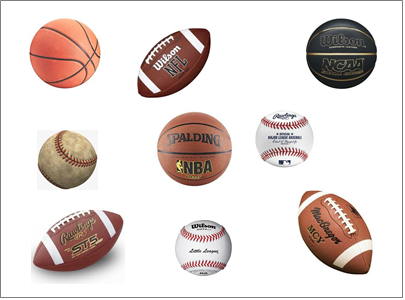

In [11]:
from IPython.display import Image
Image('figures/ClusteringExample.png', width=600)

The goal in clustering is to partition the data into groups. 
* How many groups would you partition this data into?

---

## Types of Clustering

There are many different types of clustering:

There are 5 types of clustering:

1. Centroid clustering
    * Example: K-Means
2. Density clustering
    * Example: DBSCAN
3. Distribution clustering
    * Example: Mixture Models
4. Hierarchical clustering
    * Example: Dendrogram
5. Graph clustering
    * Example: Spectral Algorithm

They differ from one another in how they assess *similarity* between points to be assigned in the same cluster.

---

### K-Means 
- Assumes **spherical, equally-sized clusters**.
- Requires the number of clusters `k` to be specified.
- Sensitive to **initialization** and **outliers**.
- Performs poorly on non-globular or uneven density clusters.

### DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
- Groups points that are **closely packed together** (density).
- Does **not require the number of clusters** to be specified.
- Can identify **arbitrary-shaped clusters** and **noise/outliers**.
- Parameters:
  - `eps`: The radius within which to search for neighboring points.
  - `min_samples`: Minimum number of neighbors to form a dense region.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from ipywidgets import interact, FloatSlider, IntSlider, Checkbox

# Generate synthetic data
def generate_data(dataset='moons'):
    if dataset == 'moons':
        X, _ = make_moons(n_samples=500, noise=0.08, random_state=42)
    elif dataset == 'blobs':
        X, _ = make_blobs(n_samples=500, centers=3, cluster_std=1.0, random_state=42)
    return StandardScaler().fit_transform(X)

# Plotting function
def plot_clusters(eps=0.3, min_samples=5, overlay_boundaries=False, dataset='moons'):
    X = generate_data(dataset)

    # K-Means
    kmeans = KMeans(n_clusters=3, n_init='auto')
    y_kmeans = kmeans.fit_predict(X)

    # DBSCAN
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    y_dbscan = dbscan.fit_predict(X)

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # K-Means Plot
    axs[0].scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='tab10', s=20)
    axs[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                   c='black', s=100, marker='x')
    axs[0].set_title('K-Means Clustering')

    # DBSCAN Plot
    axs[1].scatter(X[:, 0], X[:, 1], c=y_dbscan, cmap='tab10', s=20)
    axs[1].set_title(f'DBSCAN Clustering\n(eps={eps}, min_samples={min_samples})')

    # Optional boundary overlay
    if overlay_boundaries:
        from sklearn.neighbors import NearestNeighbors
        axs[1].set_title(f'DBSCAN + Density Boundary\n(eps={eps}, min_samples={min_samples})')
        neigh = NearestNeighbors(n_neighbors=min_samples).fit(X)
        dists, _ = neigh.kneighbors(X)
        dists = np.sort(dists[:, -1])
        axs[1].plot(range(len(dists)), dists, c='gray', linewidth=1, linestyle='--')

    for ax in axs:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(True)

    plt.tight_layout()
    plt.show()

# Interactive widget
interact(plot_clusters,
         eps=FloatSlider(value=0.3, min=0.05, max=1.0, step=0.05),
         min_samples=IntSlider(value=5, min=1, max=20, step=1),
         overlay_boundaries=Checkbox(value=False, description='Overlay DBSCAN Boundaries'),
         dataset=['moons', 'blobs']);

interactive(children=(FloatSlider(value=0.3, description='eps', max=1.0, min=0.05, step=0.05), IntSlider(value…

## Interactivity
Use the sliders above and checkbox to:
- Adjust `eps` and `min_samples` to see how DBSCAN behavior changes.
- Compare K-Means’ rigid clustering with DBSCAN's flexible, density-based approach.
- Optionally overlay a **density-based k-distance plot** to better understand DBSCAN boundaries.

## Observations
- Try using the "moons" dataset to see how K-Means struggles while DBSCAN captures the shape.
- Use the "blobs" dataset to see a case where K-Means performs well.
- Tweak `eps` to explore the sensitivity of DBSCAN to neighborhood size.